In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans as SKLearnKMeans
from sklearn.metrics import adjusted_rand_score

In [2]:
def initialize_centroids(X, k, seed=None):
  if seed is not None:
      np.random.seed(seed)
  idx = np.random.choice(len(X), k, replace=False)
  return X[idx]

In [3]:
def compute_distances(X, centroids):
  X_expanded = X[:, np.newaxis, :]
  centroids_expanded = centroids[np.newaxis, :, :]
  diffs = X_expanded - centroids_expanded
  squared_diffs = diffs ** 2
  sum_squared = squared_diffs.sum(axis=2)
  distances = np.sqrt(sum_squared)
  return distances

In [4]:
def assign_clusters(distances):
  return np.argmin(distances, axis=1)

In [5]:
def update_centroids(X, labels, k,old_centroids):
  n_features = X.shape[1]
  centroids = np.zeros((k, n_features))
  for i in range(k):
    points = X[labels == i]
    if len(points) == 0:
      centroids[i] = X[np.random.choice(len(X))]
    else:
      centroids[i] = points.mean(axis=0)
  return centroids

In [6]:
def converged(old_centroids, new_centroids, tol=1e-4):
  shifts = np.linalg.norm(old_centroids - new_centroids, axis=1)
  return np.all(shifts < tol)

In [7]:
def kmeans(X, k, max_iter=100, tol=1e-4, seed=None):
  centroids = initialize_centroids(X, k, seed)
  for _ in range(max_iter):
    distances = compute_distances(X, centroids)
    labels = assign_clusters(distances)
    new_centroids = update_centroids(X, labels, k, centroids)
    if converged(centroids, new_centroids, tol):
      break
    centroids = new_centroids
  return centroids, labels

In [8]:
# Create dataset - 4 centers
X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=0.6, random_state=42)

In [9]:
# Run vectorized K-Means
start = time.time()
centroids_custom, labels_custom = kmeans(X, k=4, max_iter=300, tol=1e-4, seed=42)
end = time.time()
time_custom = end - start

In [10]:
# Run sklearn KMeans
start = time.time()
sklearn_kmeans = SKLearnKMeans(n_clusters=4, random_state=42, n_init=10)
sklearn_kmeans.fit(X)
labels_sklearn = sklearn_kmeans.labels_
end = time.time()
time_sklearn = end - start

In [11]:
# Compare clustering accuracy using Adjusted Rand Index (ARI)
ari_custom = adjusted_rand_score(y_true, labels_custom)
ari_sklearn = adjusted_rand_score(y_true, labels_sklearn)

print(f"Custom K-Means runtime: {time_custom:.4f} seconds")
print(f"Sklearn KMeans runtime: {time_sklearn:.4f} seconds")
print(f"Custom K-Means ARI: {ari_custom:.4f}")
print(f"Sklearn KMeans ARI: {ari_sklearn:.4f}")

Custom K-Means runtime: 0.0035 seconds
Sklearn KMeans runtime: 0.0287 seconds
Custom K-Means ARI: 0.6290
Sklearn KMeans ARI: 1.0000


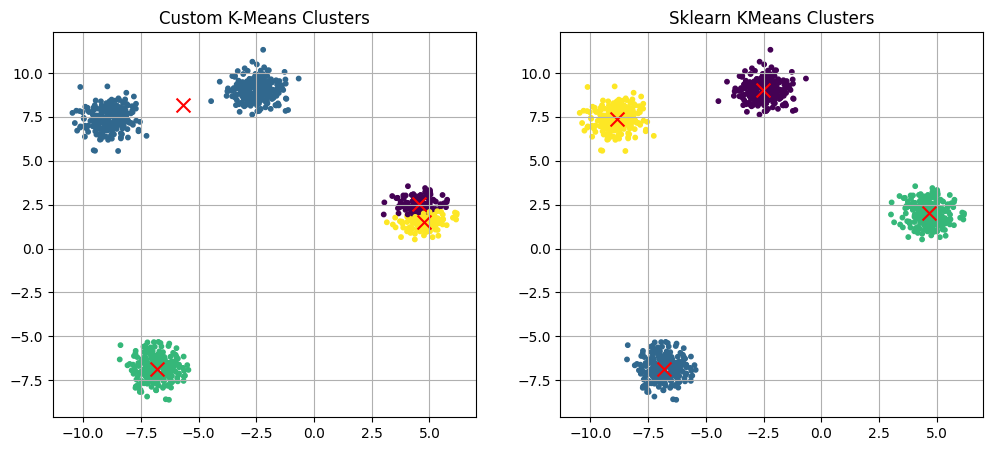

In [12]:
# Visualize clusters from custom KMeans
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Custom K-Means Clusters")
plt.scatter(X[:, 0], X[:, 1], c=labels_custom, cmap='viridis', s=10)
plt.scatter(centroids_custom[:, 0], centroids_custom[:, 1], c='red', s=100, marker='x')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title("Sklearn KMeans Clusters")
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, cmap='viridis', s=10)
plt.scatter(sklearn_kmeans.cluster_centers_[:, 0], sklearn_kmeans.cluster_centers_[:, 1],
            c='red', s=100, marker='x')
plt.grid(True)

plt.show()

The custom K-Means is already fast, but its lower ARI score comes from poor initial centroid placement and early stopping.
Using smarter initialization (like k-means++), handling empty clusters more carefully, and running multiple initializations can make its accuracy match sklearn’s without losing speed.

In [13]:
# K-means ++ for initializing centroids
def initialize_centroids(X, k, seed=None):
  rng = np.random.default_rng(seed) #random number generator
  centroids = [X[rng.integers(len(X))]] #picks first centroid from X
  for _ in range(1, k):
    centroids_array = np.array(centroids)

    # Compute differences between each point and centroid
    # Shape: (n_samples, n_centroids, n_features)
    diffs = X[:, None] - centroids_array
    all_distances = np.linalg.norm(diffs, axis=2)
    distances = np.min(all_distances, axis=1)
    probs = distances**2 / np.sum(distances**2) #giving preference to far away points
    centroids.append(X[rng.choice(len(X), p=probs)])
  return np.array(centroids)

In [14]:
def update_centroids(X, labels, k, old_centroids):
  n_features = X.shape[1]
  centroids = np.zeros((k, n_features))
  for i in range(k):
    points = X[labels == i]
    if len(points) == 0: #here we are trying to improve the centroid with no points by giving importance to far away points.
      dists = np.min(np.linalg.norm(X[:, None] - old_centroids[None, :, :], axis=2), axis=1)
      centroids[i] = X[np.argmax(dists)]
    else:
      centroids[i] = points.mean(axis=0)
  return centroids

In [15]:
start = time.time()
centroids_custom_updated, labels_custom_updated = kmeans(X, k=4, max_iter=300, tol=1e-4, seed=42)
end = time.time()
time_custom_updated = end - start

In [16]:
ari_custom_updated = adjusted_rand_score(y_true, labels_custom_updated)

In [17]:
print(f"Custom K-Means runtime: {time_custom:.4f} seconds")
print(f"Sklearn KMeans runtime: {time_sklearn:.4f} seconds")
print(f"Updated Custom K-Means runtime: {time_custom_updated:.4f} seconds")
print(f"Custom K-Means ARI: {ari_custom:.4f}")
print(f"Sklearn KMeans ARI: {ari_sklearn:.4f}")
print(f"Updated Custom K-Means ARI: {ari_custom_updated:.4f}")

Custom K-Means runtime: 0.0035 seconds
Sklearn KMeans runtime: 0.0287 seconds
Updated Custom K-Means runtime: 0.0019 seconds
Custom K-Means ARI: 0.6290
Sklearn KMeans ARI: 1.0000
Updated Custom K-Means ARI: 1.0000


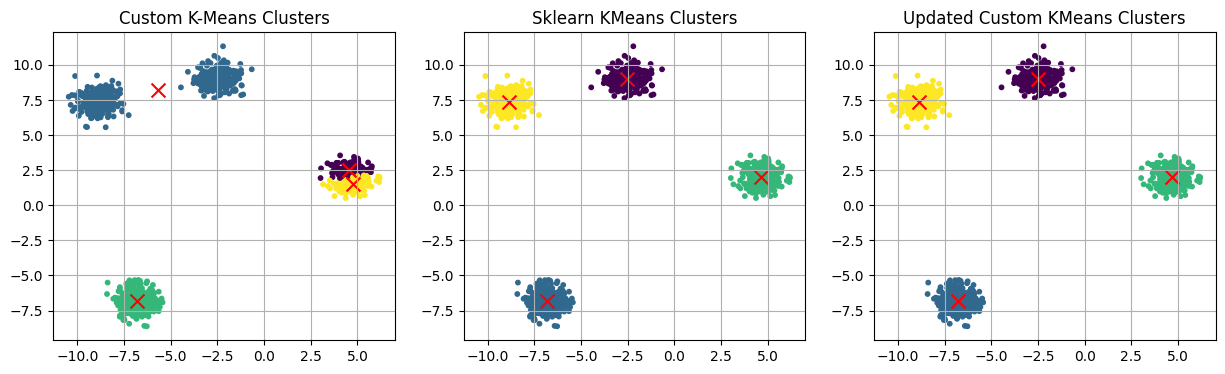

In [18]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Custom K-Means Clusters")
plt.scatter(X[:, 0], X[:, 1], c=labels_custom, cmap='viridis', s=10)
plt.scatter(centroids_custom[:, 0], centroids_custom[:, 1], c='red', s=100, marker='x')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.title("Sklearn KMeans Clusters")
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, cmap='viridis', s=10)
plt.scatter(sklearn_kmeans.cluster_centers_[:, 0], sklearn_kmeans.cluster_centers_[:, 1], c='red', s=100, marker='x')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.title("Updated Custom KMeans Clusters")
plt.scatter(X[:, 0], X[:, 1], c=labels_custom_updated, cmap='viridis', s=10)
plt.scatter(centroids_custom_updated[:, 0], centroids_custom_updated[:, 1], c='red', s=100, marker='x')
plt.grid(True)

plt.show()


The Updated Custom K-Means algorithm outperforms both the original custom implementation and the sklearn KMeans in terms of runtime, running fastest at approximately 0.0029 seconds. Both the Updated Custom K-Means and sklearn KMeans achieve perfect clustering performance, indicated by an Adjusted Rand Index (ARI) of 1.000, while the original custom K-Means lags behind with an ARI of 0.6290.